In [15]:
import pandas as pd

df = pd.read_csv("../data/booking_reviews_cleaned.csv")

In [16]:
df.head(1)

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,trip_type,traveller_type,stay_length
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,Business trip,Solo traveller,Stayed 1 night


In [3]:
texts = df["review_text"].fillna("").astype(str)

print("Number of reviews:", len(texts))
texts.head()

Number of reviews: 26056


0    Everything was perfect! Quite, cozy place to r...
1            Very friendly host and perfect breakfast!
2    It was just what we wanted for a week by the b...
3    My stay in the house was a experiencing bliss ...
4    The building itself has a very musty smell in ...
Name: review_text, dtype: str

In [4]:
# process:
# TF-IDF → NMF Topic Model → assign topic per review → analyze topics by rating/business variables


# Topic Modeling

# After sentiment analysis, topic modeling is used to understand what hotel guests are actually talking about in their reviews.

# Sentiment analysis tells us whether a review sounds positive or negative, while topic modeling helps identify the main themes behind the reviews, 
# such as location, staff, cleanliness, breakfast, room quality, noise, comfort, or facilities.

# For this first topic modeling approach, TF-IDF is used to convert the review text into numerical features, 
# and NMF is used to discover groups of words that often appear together.

In [17]:
# TF-IDF matrix:

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2)
)

X_tfidf = tfidf_vectorizer.fit_transform(texts)

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (26056, 5000)


In [6]:
# what this means: 

# TF-IDF converts each review into numerical features based on how important each word or phrase is. 
# Common English stopwords are removed, very rare words are ignored, and very frequent words are also reduced because they are less useful for distinguishing topics.

In [18]:
# now for NMF: 

# NMF, or Non-negative Matrix Factorization, is used here as a topic modeling method. After the review text is converted into TF-IDF numerical features, 
# NMF looks for groups of words that frequently appear together and uses them to create topics. Each topic is represented by its most important words. 
# The model does not automatically name the topics, so the topic names are interpreted manually by looking at the top words and example reviews.

from sklearn.decomposition import NMF

n_topics = 8

nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    max_iter=500
)

topic_matrix = nmf_model.fit_transform(X_tfidf)

print("Topic matrix shape:", topic_matrix.shape)


Topic matrix shape: (26056, 8)


In [13]:
# top words per topic: 

feature_names = tfidf_vectorizer.get_feature_names_out()

def show_topics(model, feature_names, n_words=15):
    for topic_idx, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[-n_words:][::-1]
        top_words = [feature_names[i] for i in top_word_indices]
        
        print(f"Topic {topic_idx}:")
        print(", ".join(top_words))
        print("-" * 100)

show_topics(nmf_model, feature_names, n_words=15)

Topic 0:
available review, comments available, review, comments, available, parking available, tea, available room, coffee, parking, coffee available, tea coffee, room available, food available, breakfast available
----------------------------------------------------------------------------------------------------
Topic 1:
room, nice, hotel, clean, comfortable, bed, bathroom, really, small, shower, rooms, close, stay, place, like
----------------------------------------------------------------------------------------------------
Topic 2:
location, good location, great location, central, excellent location, central location, location good, perfect location, location perfect, location staff, location clean, location location, location nice, nice location, location great
----------------------------------------------------------------------------------------------------
Topic 3:
good, good location, good breakfast, location good, breakfast good, value, breakfast, good value, value money, 

In [9]:
### Interpreting the Initial Topics

##### The NMF topic model has generated 8 topics based on word patterns in the `review_text` column. Each topic is represented by its most important words. 
##### These words help us understand the main theme of each group of reviews.
##### Some topics are already easy to interpret. For example, Topic 2 is clearly related to **location**, Topic 4 is related to **staff and service**, 
##### and Topic 7 is strongly related to **breakfast**. Other topics are more general, using words like “good,” “great,” and “perfect,” 
##### which suggests that the model is also capturing broad positive review language rather than only specific hotel-service themes.
##### At this stage, the topic names are not final. The next step is to inspect sample reviews from each topic, 
##### because topic modeling does not automatically understand meaning. We need to manually name each topic based on both the top words and the actual review examples.

In [19]:
df.head(1)

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,trip_type,traveller_type,stay_length
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,Business trip,Solo traveller,Stayed 1 night


In [20]:
# Assign each review to the topic with the highest NMF score
df["topic_id"] = topic_matrix.argmax(axis=1)

df[["review_text", "rating", "topic_id"]].head(10)

,review_text,rating,topic_id
0,"Everything was perfect! Quite, cozy place to r...",10.0,5
1,Very friendly host and perfect breakfast!,9.0,5
2,It was just what we wanted for a week by the b...,10.0,2
3,My stay in the house was a experiencing bliss ...,10.0,1
4,The building itself has a very musty smell in ...,9.2,1
5,"Nothing,\n\nBeautiful home! Great room, most c...",10.0,6
6,to many messages sending from the owner in the...,10.0,5
7,"Spacious, more than enough rooms, a lot of bat...",8.3,1
8,There are no comments available for this review,9.2,0
9,"nothing -- place was perfect,\n\nThis is an ex...",10.0,5


In [21]:
topic_name_map = {
    0: "Amenities & Parking",
    1: "Room Comfort",
    2: "Location",
    3: "Value & Breakfast",
    4: "Staff & Service",
    5: "Perfect Stay",
    6: "Great Overall Experience",
    7: "Breakfast & Hospitality"
}

df["topic_name"] = df["topic_id"].map(topic_name_map)

df[["review_text", "rating", "topic_id", "topic_name"]].head(10)

,review_text,rating,topic_id,topic_name
0,"Everything was perfect! Quite, cozy place to r...",10.0,5,Perfect Stay
1,Very friendly host and perfect breakfast!,9.0,5,Perfect Stay
2,It was just what we wanted for a week by the b...,10.0,2,Location
3,My stay in the house was a experiencing bliss ...,10.0,1,Room Comfort
4,The building itself has a very musty smell in ...,9.2,1,Room Comfort
5,"Nothing,\n\nBeautiful home! Great room, most c...",10.0,6,Great Overall Experience
6,to many messages sending from the owner in the...,10.0,5,Perfect Stay
7,"Spacious, more than enough rooms, a lot of bat...",8.3,1,Room Comfort
8,There are no comments available for this review,9.2,0,Amenities & Parking
9,"nothing -- place was perfect,\n\nThis is an ex...",10.0,5,Perfect Stay


In [22]:
topic_rating_summary = (
    df.groupby("topic_id")
    .agg(
        review_count=("review_text", "count"),
        avg_rating=("rating", "mean"),
        median_rating=("rating", "median")
    )
    .sort_values("avg_rating")
)

topic_rating_summary

,review_count,avg_rating,median_rating
topic_id,,,
1,6530,8.079571,8.8
2,1429,8.255773,8.8
3,2389,8.450649,8.8
0,7820,8.646586,9.0
4,2566,8.743063,9.0
7,2222,8.916517,9.5
6,1858,9.096071,9.6
5,1242,9.303623,10.0


In [23]:
topic_counts = (
    df["topic_name"]
    .value_counts()
    .reset_index()
)

topic_counts.columns = ["topic_name", "review_count"]

topic_counts

,topic_name,review_count
0,Amenities & Parking,7820
1,Room Comfort,6530
2,Staff & Service,2566
3,Value & Breakfast,2389
4,Breakfast & Hospitality,2222
5,Great Overall Experience,1858
6,Location,1429
7,Perfect Stay,1242


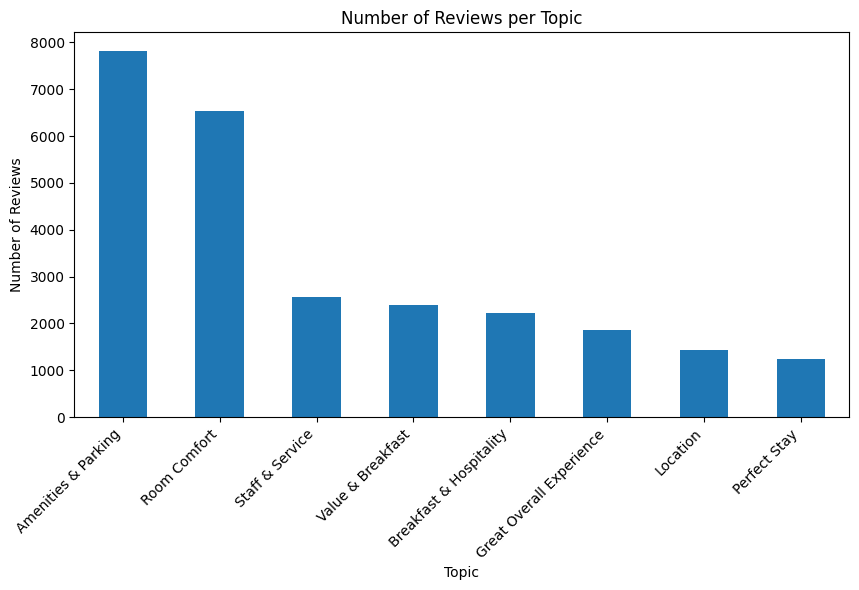

In [24]:
import matplotlib.pyplot as plt

topic_counts.plot(
    x="topic_name",
    y="review_count",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

plt.title("Number of Reviews per Topic")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.show()

In [25]:
# average rating per topic

In [26]:
topic_rating_summary = (
    df.groupby("topic_name")
    .agg(
        review_count=("review_text", "count"),
        avg_rating=("rating", "mean"),
        median_rating=("rating", "median")
    )
    .sort_values("avg_rating")
)

topic_rating_summary

,review_count,avg_rating,median_rating
topic_name,,,
Room Comfort,6530,8.079571,8.8
Location,1429,8.255773,8.8
Value & Breakfast,2389,8.450649,8.8
Amenities & Parking,7820,8.646586,9.0
Staff & Service,2566,8.743063,9.0
Breakfast & Hospitality,2222,8.916517,9.5
Great Overall Experience,1858,9.096071,9.6
Perfect Stay,1242,9.303623,10.0


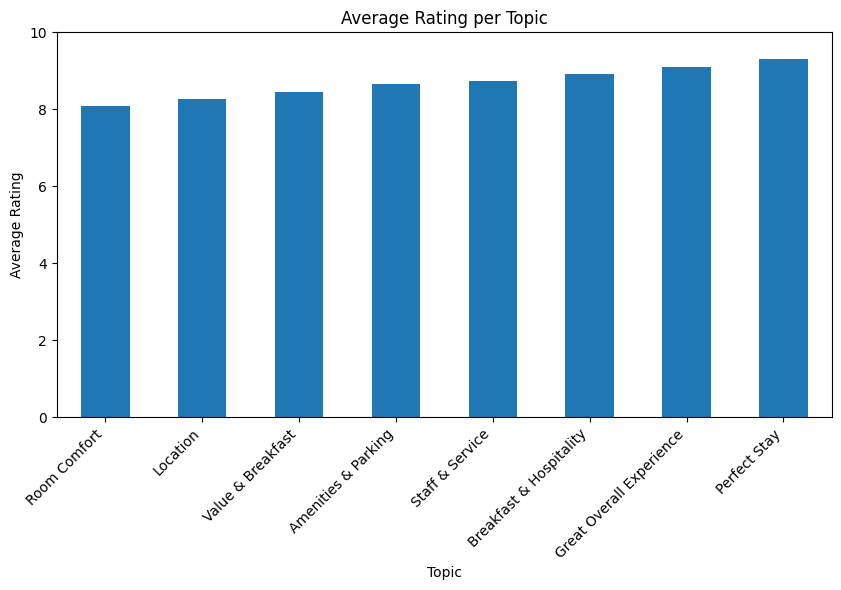

In [27]:
topic_rating_summary["avg_rating"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Rating per Topic")
plt.xlabel("Topic")
plt.ylabel("Average Rating")
plt.ylim(0, 10)
plt.xticks(rotation=45, ha="right")
plt.show()

In [28]:
topic_by_season = pd.crosstab(
    df["topic_name"],
    df["season"],
    normalize="index"
).round(2)

topic_by_season

season,Autumn,Spring,Summer,Winter
topic_name,,,,
Amenities & Parking,0.30,0.18,0.29,0.23
Breakfast & Hospitality,0.32,0.17,0.29,0.22
Great Overall Experience,0.29,0.17,0.30,0.24
Location,0.31,0.19,0.28,0.22
Perfect Stay,0.29,0.17,0.29,0.25
Room Comfort,0.30,0.17,0.28,0.25
Staff & Service,0.29,0.18,0.30,0.23
Value & Breakfast,0.28,0.19,0.29,0.24


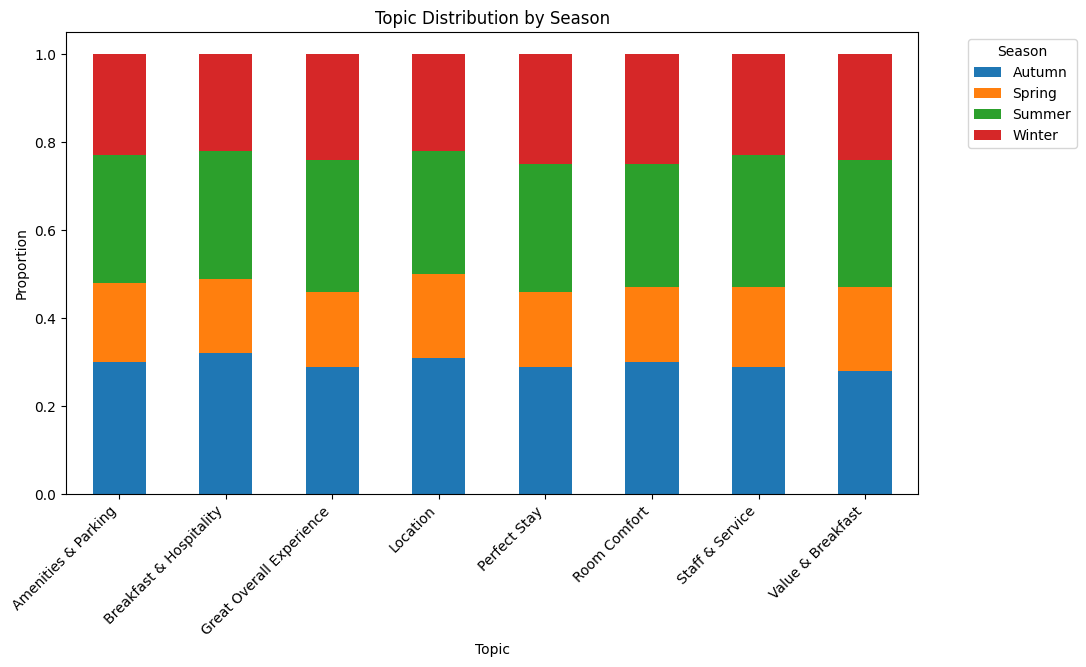

In [29]:
topic_by_season.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Topic Distribution by Season")
plt.xlabel("Topic")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [30]:
# topic by trip type

In [31]:
topic_by_trip_type = pd.crosstab(
    df["topic_name"],
    df["trip_type"],
    normalize="index"
).round(2)

topic_by_trip_type

trip_type,Business trip,Couple,Family with young children,Group,Leisure trip,People with friends,Solo traveller,With a pet
topic_name,,,,,,,,
Amenities & Parking,0.25,0.01,0.01,0.0,0.72,0.00,0.01,0.00
Breakfast & Hospitality,0.19,0.01,0.00,0.0,0.78,0.00,0.01,0.01
Great Overall Experience,0.16,0.01,0.01,0.0,0.82,0.00,0.01,0.00
Location,0.20,0.01,0.01,0.0,0.78,0.00,0.01,0.00
Perfect Stay,0.16,0.01,0.00,0.0,0.81,0.00,0.01,0.01
Room Comfort,0.21,0.01,0.01,0.0,0.75,0.00,0.01,0.00
Staff & Service,0.19,0.01,0.01,0.0,0.78,0.00,0.01,0.01
Value & Breakfast,0.22,0.01,0.01,0.0,0.74,0.01,0.01,0.00


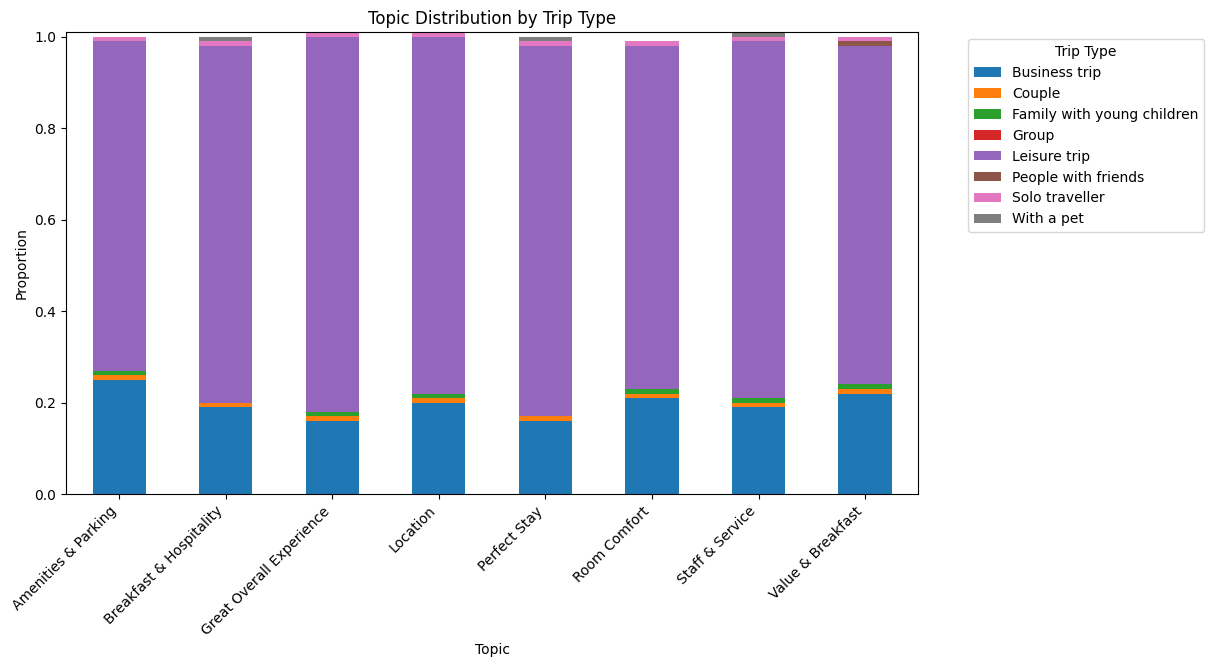

In [32]:
topic_by_trip_type.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Topic Distribution by Trip Type")
plt.xlabel("Topic")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Trip Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [33]:
# topic by traveller type

In [34]:
topic_by_traveller = pd.crosstab(
    df["topic_name"],
    df["traveller_type"],
    normalize="index"
).round(2)

topic_by_traveller

traveller_type,Apartment,Apartment (4 Adults),Apartment - Ground Floor,Apartment with Balcony,Apartment with Garden View,Apartment with Terrace,Basic Triple Room - Basement,Bed in 16-Bed Mixed Dormitory Room,Bed in 4 Bed Mixed Dorm,Bed in 4-Bed Female Dormitory Room,...,Twin Room with Garden View,Twin Room with Private Bathroom,Two-Bedroom Apartment,Two-Bedroom Apartment with Terrace,Two-Bedroom Chalet,Two-Bedroom House,Villa,Wonderful Room with Spa Bath,penta Junior Suite,penta Standard Double or Twin Room
topic_name,,,,,,,,,,,,,,,,,,,,,
Amenities & Parking,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Breakfast & Hospitality,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Great Overall Experience,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Location,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Perfect Stay,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Room Comfort,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Staff & Service,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Value & Breakfast,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


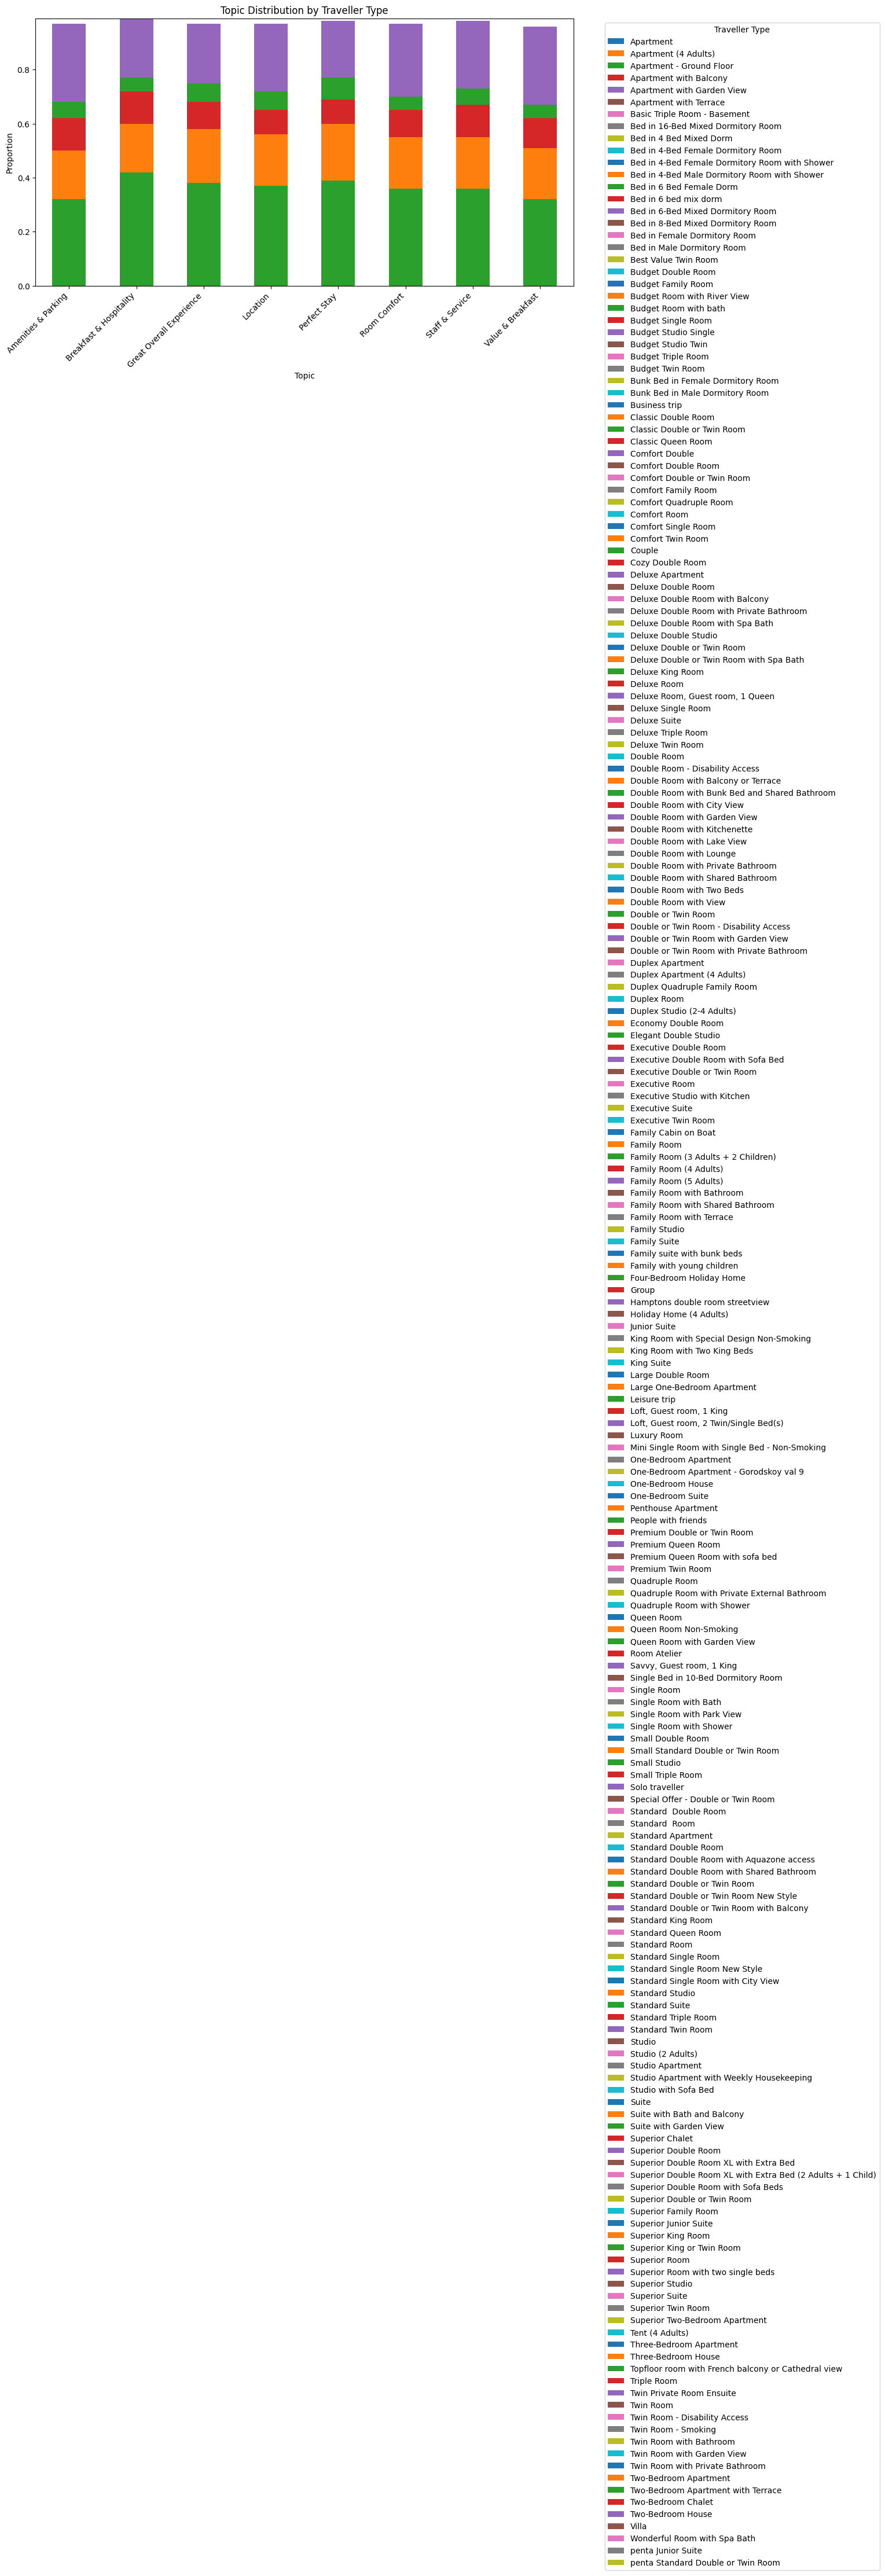

In [35]:
topic_by_traveller.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Topic Distribution by Traveller Type")
plt.xlabel("Topic")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Traveller Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [36]:
# fix this with PROPER DF!! 

In [37]:
# sample reviews with topic names

pd.set_option("display.max_colwidth", 300)

for topic_name in df["topic_name"].dropna().unique():
    print("=" * 100)
    print(topic_name)
    print("=" * 100)
    
    display(
        df[df["topic_name"] == topic_name][
            ["review_text", "rating", "hotel_name", "season", "trip_type", "traveller_type"]
        ].head(5)
    )

Perfect Stay


,review_text,rating,hotel_name,season,trip_type,traveller_type
0,"Everything was perfect! Quite, cozy place to relax.",10.0,Villa Pura Vida,Summer,Business trip,Solo traveller
1,Very friendly host and perfect breakfast!,9.0,Villa Pura Vida,Autumn,Leisure trip,Couple
6,"to many messages sending from the owner in the app. But it is only my filling.,\n\neverything great! perfect location, perfect room, very clean, everything what you need inside, but the best of the best is the bath :)",10.0,Love Nest Versailles - Unique Louis XIV decoration - Calm location right IN city center,Summer,Business trip,Couple
9,"nothing -- place was perfect,\n\nThis is an excellent place to stay and I highly recommend staying there. The stay is extremely helpful. One of the best places I have stayed -- it is that good.",10.0,Villa Pura Vida,Summer,Business trip,Group
17,"Nothing!,\n\nPerfect! Near the central station and another facilities",10.0,Love Nest Versailles - Unique Louis XIV decoration - Calm location right IN city center,Winter,Leisure trip,Couple


Location


,review_text,rating,hotel_name,season,trip_type,traveller_type
2,"It was just what we wanted for a week by the beach in winter,\n\nLocation was fab, apartment quiet and very well-equipped. Spotless clean.",10.0,Hydro Palace Apartment,Winter,Leisure trip,Couple
52,"The bathroom can only be reached through the bedroom.,\n\nIt's in the heart of the city, fantastic location!",9.0,Le Studio de Christine,Summer,Leisure trip,Group
54,"I loved it, brilliant location, sparkling clean, amazing minimal decor. Very comfy bed, amenities fabulous.",9.6,Minimalistic In Premium Location,Autumn,Business trip,Family with young children
68,"none,\n\nRoom, location, breakfast - everything according to prior expectations.",9.0,Marivaux Hotel,Spring,Business trip,Solo traveller
77,Location,9.6,Le Studio de Christine,Spring,Leisure trip,Group


Room Comfort


...

,review_text,rating,hotel_name,season,trip_type,traveller_type
14,The breakfast should be better for that hotel level.,9.0,Novotel Gent Centrum,Summer,Business trip,Family with young children
15,"The B&B is located just next to Place Jourdan, so there are various options for dinner in the evening. The family is super nice and helpful and the breakfast is prepared in advance so everything is super COVID-safe!",10.0,B&B Place Jourdan,Autumn,Business trip,Solo traveller
16,"Nothing,\n\nThe peacefulness, the spectacular decor, the kindness of the hosts, nothing was to much trouble",9.6,Villa Pura Vida,Spring,Leisure trip,Couple
26,"Excellent breakfast\rVery professional staff, ready to help to get your preferred room if you already went at this hotel.",9.2,Hotel Saint Sauveur by WP Hotels,Autumn,Leisure trip,Couple
29,"Nothing ,\n\nLovely welcome. Really clean and real attention to detail with the lovely breakfast. Thank you!",10.0,B&B Place Jourdan,Winter,Leisure trip,Solo traveller


Value & Breakfast


,review_text,rating,hotel_name,season,trip_type,traveller_type
20,"nothing,\n\nBreakfast was super and more then enough. Super friendly host and very flexible. The B&B also had a very good parkinglot, easily accesible.",9.0,B&B Hof Beygaert,Winter,Leisure trip,Couple
28,"The matrasses where to soft for me, but that's person related.,\n\nKind staff, good location to explore the city.",8.0,Novotel Gent Centrum,Summer,Leisure trip,Family with young children
35,"It was new, cozy, and the owner was a nice person. The breakfast was amazing. Very good value!",9.6,B&B Hof Beygaert,Autumn,Leisure trip,Family with young children
38,"A great private atmosphere, good facilities and the experience of nature and city perfectly united.",10.0,Villa Pura Vida,Spring,Business trip,Group
40,Very good location\ncosy and spacious appartment\nVery kind hostess,9.0,Le Studio de Christine,Autumn,Leisure trip,Couple


Staff & Service


,review_text,rating,hotel_name,season,trip_type,traveller_type
27,"Private parking area, pretty much brand new building, modern but cozy and warm, tastefully decorated, very friendly owner.",10.0,B&B Hof Beygaert,Winter,Couple,Deluxe Double Studio
32,Staff ap friendly and Helpful. Thank you,10.0,Marivaux Hotel,Spring,Leisure trip,Couple
36,It needs to be more clean. But it is in an excellent location and the staff was very friendly!!!,7.0,Novotel Gent Centrum,Spring,Leisure trip,Family with young children
37,"Very small table - not really appropriate for work.,\n\nVery friendly host. Very quiet over night.",8.0,B&B Place Jourdan,Winter,Business trip,Solo traveller
39,"Broken shower and TV.,\n\nThe room was satisfactory apart from the bathroom. The hotel has also a nice restaurant which was probably the only place in town to eat in the evening. The staff was very friendly.",7.1,AppartHotel Belle Vue,Autumn,Leisure trip,Family with young children


In [38]:
# we will use the otehr dataset with the training, to get 'which words appear most often in negative reviews vs positive reviews'

In [39]:
df_tran = pd.read_csv("C:\\Users\\marga\\Desktop\\AIEngineering_BBDA\\Hotel-Reviews-Sentiment-Analysis-NLP-Project\\data\\booking_reviews_with_two_transformer_predictions.csv")

df_tran.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,trip_type,traveller_type,stay_length,transformer_label,transformer_score,rating_sentiment_binary,star_transformer_label,star_transformer_score,rating_5_star_label,star_transformer_binary
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to relax.",2021,July,Summer,Business trip,Solo traveller,Stayed 1 night,POSITIVE,0.999868,POSITIVE,5 stars,0.716760,5 stars,POSITIVE
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,2019,November,Autumn,Leisure trip,Couple,Stayed 1 night,POSITIVE,0.999887,POSITIVE,5 stars,0.836870,5 stars,POSITIVE
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,"It was just what we wanted for a week by the beach in winter,\n\nLocation was fab, apartment quiet and very well-equipped. Spotless clean.",2020,January,Winter,Leisure trip,Couple,Stayed 6 nights,POSITIVE,0.839765,POSITIVE,5 stars,0.666776,5 stars,POSITIVE
3,My stay in the house was a experiencing bliss in luxury. The house is sheer touch of beauty wrapped,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss in luxury. The house is sheer touch of beauty wrapped by luxury and complimented with kindness and care from Lisbette & her parents making it a most remarkable stay.,2019,September,Autumn,Business trip,Solo traveller,Stayed 4 nights,POSITIVE,0.999888,POSITIVE,5 stars,0.803107,5 stars,POSITIVE
4,"One bedroom apartment with wonderful view and free, secure parking, but not close enough to the main beach area.",Hydro Palace Apartment,9.2,South Africa,9.2,"The building itself has a very musty smell in the hallway (despite being built in 1988), but the apartment itself smells good, which makes it bearable. \nWhen showering, the hot water goes off every 2-3 minutes for about 20-30 seconds and then only cold water comes out. The hot water then comes ...",2019,June,Summer,Leisure trip,People with friends,Stayed 4 nights,NEGATIVE,0.779410,POSITIVE,3 stars,0.394768,5 stars,NEGATIVE


In [40]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
import pandas as pd
import matplotlib.pyplot as plt

positive_texts = df_tran[df_tran["rating_sentiment_binary"] == "POSITIVE"]["review_text"].fillna("").astype(str)

negative_texts = df_tran[df_tran["rating_sentiment_binary"] == "NEGATIVE"]["review_text"].fillna("").astype(str)

In [41]:
custom_stop_words = list(ENGLISH_STOP_WORDS.union([
    "hotel", "room", "rooms", "stay", "stayed", "place", "apartment",
    "apartments", "really", "just", "good", "great", "nice",
    "booking", "com", "guest", "guests", "did", "does", "don",
    "wasn", "isn", "didn", "night", "nights"
]))

In [42]:
def get_top_words(texts, n=10):
    vectorizer = CountVectorizer(
        stop_words=custom_stop_words,
        max_features=5000,
        ngram_range=(1, 1)
    )
    
    word_matrix = vectorizer.fit_transform(texts)
    
    word_counts = word_matrix.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()
    
    word_freq = pd.DataFrame({
        "word": words,
        "count": word_counts
    })
    
    return word_freq.sort_values("count", ascending=False).head(n)

In [43]:
top_positive_words = get_top_words(positive_texts, n=10)
top_negative_words = get_top_words(negative_texts, n=10)

top_positive_words

,word,count
402,available,6075
1009,comments,5719
3762,review,5713
2606,location,4849
667,breakfast,4747
4182,staff,3676
935,clean,3094
1887,friendly,2822
1003,comfortable,2236
1584,excellent,1790


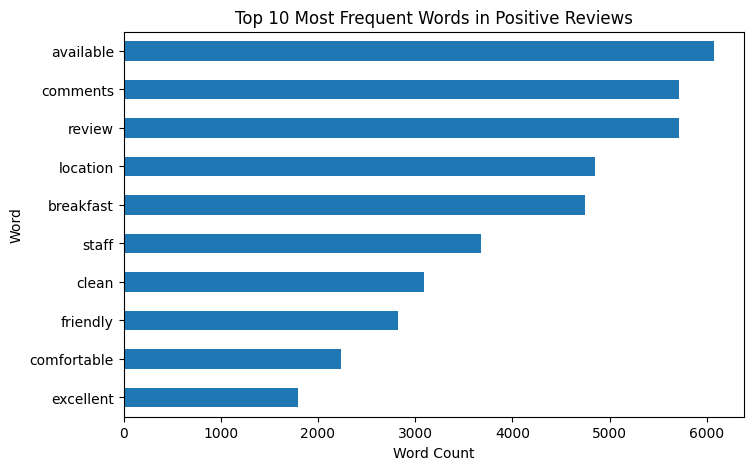

In [44]:
# top ten positive words: 

top_positive_words.sort_values("count").plot(
    x="word",
    y="count",
    kind="barh",
    legend=False,
    figsize=(8, 5)
)

plt.title("Top 10 Most Frequent Words in Positive Reviews")
plt.xlabel("Word Count")
plt.ylabel("Word")
plt.show()

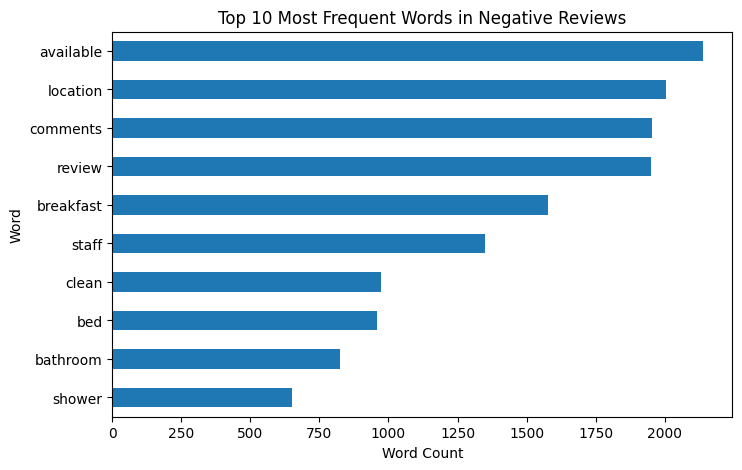

In [45]:
# top ten negative words: 

top_negative_words.sort_values("count").plot(
    x="word",
    y="count",
    kind="barh",
    legend=False,
    figsize=(8, 5)
)

plt.title("Top 10 Most Frequent Words in Negative Reviews")
plt.xlabel("Word Count")
plt.ylabel("Word")
plt.show()

In [46]:
top_words_comparison = pd.DataFrame({
    "positive_words": top_positive_words["word"].values,
    "positive_count": top_positive_words["count"].values,
    "negative_words": top_negative_words["word"].values,
    "negative_count": top_negative_words["count"].values
})

top_words_comparison

,positive_words,positive_count,negative_words,negative_count
0,available,6075,available,2138
1,comments,5719,location,2005
2,review,5713,comments,1953
3,location,4849,review,1949
4,breakfast,4747,breakfast,1578
5,staff,3676,staff,1349
6,clean,3094,clean,974
7,friendly,2822,bed,958
8,comfortable,2236,bathroom,825
9,excellent,1790,shower,650


In [47]:
# since they appear similar, we will try to so 'distinctive words' - which words appear proportionally more in negative reviews than positive reviews

In [48]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

custom_stop_words = list(ENGLISH_STOP_WORDS.union([
    "hotel", "room", "rooms", "stay", "stayed", "place", "apartment",
    "apartments", "really", "just", "good", "great", "nice",
    "booking", "com", "guest", "guests", "review", "comments",
    "available", "location",
    
    # likely names / named entities
    "mario", "nathalie", "maria", "katrien", "martine", "ieper"
]))

positive_texts = df_tran[df_tran["rating_sentiment_binary"] == "POSITIVE"]["review_text"].fillna("").astype(str)
negative_texts = df_tran[df_tran["rating_sentiment_binary"] == "NEGATIVE"]["review_text"].fillna("").astype(str)

vectorizer = CountVectorizer(
    stop_words=custom_stop_words,
    max_features=5000,
    ngram_range=(1, 1)
)

X_pos = vectorizer.fit_transform(positive_texts)
positive_counts = np.asarray(X_pos.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()

# Use the same vocabulary for negative texts
X_neg = vectorizer.transform(negative_texts)
negative_counts = np.asarray(X_neg.sum(axis=0)).flatten()

word_compare = pd.DataFrame({
    "word": words,
    "positive_count": positive_counts,
    "negative_count": negative_counts
})

word_compare["positive_rate"] = word_compare["positive_count"] / word_compare["positive_count"].sum()
word_compare["negative_rate"] = word_compare["negative_count"] / word_compare["negative_count"].sum()

word_compare["negative_vs_positive_ratio"] = (
    (word_compare["negative_rate"] + 1e-6) /
    (word_compare["positive_rate"] + 1e-6)
)

distinctive_negative_words = (
    word_compare[word_compare["negative_count"] >= 20]
    .sort_values("negative_vs_positive_ratio", ascending=False)
    .head(15)
)

distinctive_negative_words

,word,positive_count,negative_count,positive_rate,negative_rate,negative_vs_positive_ratio
419,badly,5,37,0.000027,0.000428,15.432193
4679,unacceptable,3,21,0.000016,0.000243,14.281113
1340,dirty,41,265,0.000220,0.003062,13.891190
403,awful,8,50,0.000043,0.000578,13.204357
3803,rude,12,72,0.000064,0.000832,12.766583
4179,stained,5,28,0.000027,0.000324,11.687176
2229,horrible,6,30,0.000032,0.000347,10.495831
4954,worst,9,41,0.000048,0.000474,9.652630
1339,dirt,6,27,0.000032,0.000312,9.449267
4049,smelly,10,44,0.000054,0.000508,9.340680


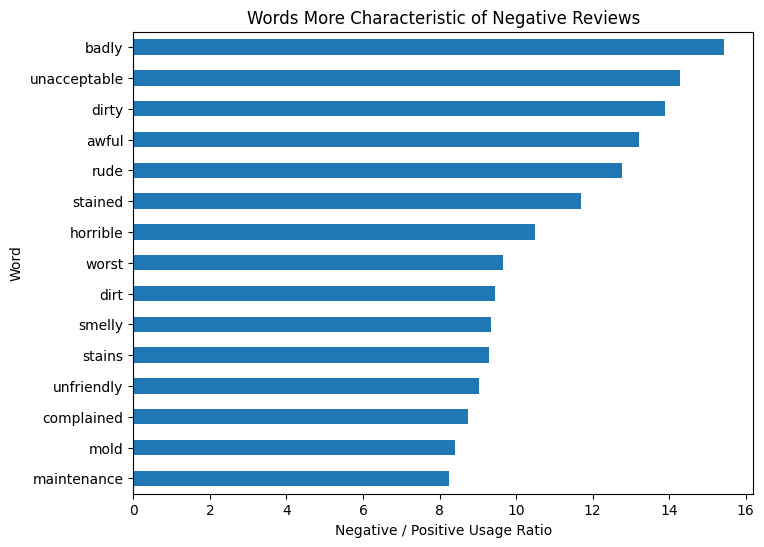

In [49]:
distinctive_negative_words.sort_values("negative_vs_positive_ratio").plot(
    x="word",
    y="negative_vs_positive_ratio",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Words More Characteristic of Negative Reviews")
plt.xlabel("Negative / Positive Usage Ratio")
plt.ylabel("Word")
plt.show()

In [50]:
# same for postiive: 

word_compare["positive_vs_negative_ratio"] = (
    (word_compare["positive_rate"] + 1e-6) /
    (word_compare["negative_rate"] + 1e-6)
)

distinctive_positive_words = (
    word_compare[word_compare["positive_count"] >= 20]
    .sort_values("positive_vs_negative_ratio", ascending=False)
    .head(15)
)

distinctive_positive_words

,word,positive_count,negative_count,positive_rate,negative_rate,negative_vs_positive_ratio,positive_vs_negative_ratio
2324,informative,39,0,0.000209,0.000000,0.004767,209.793974
2278,immaculate,30,0,0.000161,0.000000,0.006188,161.610749
782,caring,25,0,0.000134,0.000000,0.007416,134.842291
2603,locally,21,0,0.000112,0.000000,0.008816,113.427524
4564,touches,45,1,0.000241,0.000012,0.051897,19.268791
4398,tastefully,35,1,0.000187,0.000012,0.066647,15.004537
427,bakery,34,1,0.000182,0.000012,0.068596,14.578112
4397,tasteful,33,1,0.000177,0.000012,0.070663,14.151687
2468,knowledgeable,30,1,0.000161,0.000012,0.077686,12.872411
2058,grocery,29,1,0.000155,0.000012,0.080347,12.445985


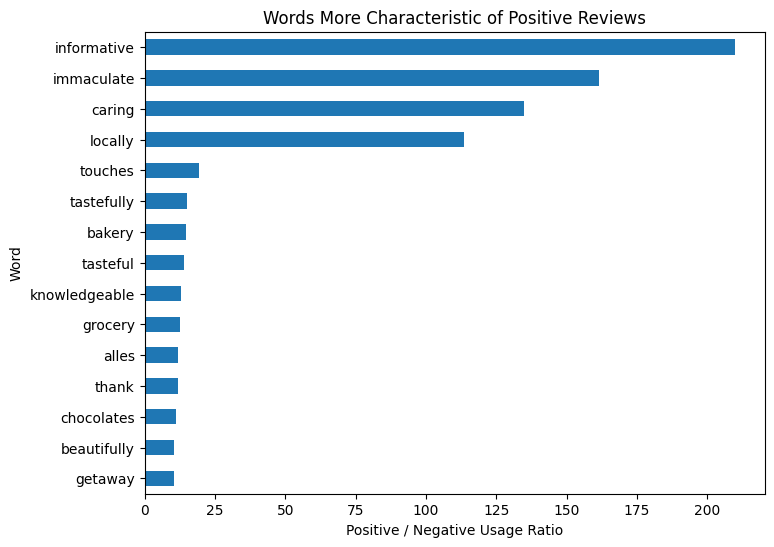

In [51]:
distinctive_positive_words.sort_values("positive_vs_negative_ratio").plot(
    x="word",
    y="positive_vs_negative_ratio",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Words More Characteristic of Positive Reviews")
plt.xlabel("Positive / Negative Usage Ratio")
plt.ylabel("Word")
plt.show()

In [52]:
# The first word-frequency plots showed very similar words for positive and negative reviews. 
# This happens because frequent words mostly capture common hotel-review vocabulary, such as location, breakfast, staff, and clean, rather than words that distinguish sentiment.

# To get more meaningful results, the analysis compares how strongly each word is associated with negative reviews relative to positive reviews, and vice versa. 
# This highlights words that are more characteristic of each sentiment group instead of simply showing the most common words overall.

In [53]:
# because we see many names, we are redoing with new stop words like names, because of NER (Named Entinty Recognition)

In [54]:
pip install en_core_web_sm

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement en_core_web_sm (from versions: none)
ERROR: No matching distribution found for en_core_web_sm


In [56]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     ------ --------------------------------- 2.1/12.8 MB 9.0 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.8 MB 8.7 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 8.8 MB/s eta 0:00:01
     ----------------------- ---------------- 7.6/12.8 MB 8.9 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 8.8 MB/s eta 0:00:01
     ----------------------------------- ---- 11.3/12.8 MB 8.8 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 8.6 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [57]:
# proepr way, use NER to identify persons, and remove them: 

import spacy

nlp = spacy.load("en_core_web_sm")

In [58]:
sample_text = df_tran["review_text"].iloc[0]

doc = nlp(sample_text)

for ent in doc.ents:
    print(ent.text, ent.label_)

In [59]:
def remove_person_names(text):
    doc = nlp(str(text))
    
    cleaned_tokens = []
    
    for token in doc:
        is_person = any(
            token.idx >= ent.start_char and token.idx < ent.end_char and ent.label_ == "PERSON"
            for ent in doc.ents
        )
        
        if not is_person:
            cleaned_tokens.append(token.text)
    
    return " ".join(cleaned_tokens)

In [60]:
from tqdm.auto import tqdm

tqdm.pandas()

df_tran["review_text_no_names"] = df_tran["review_text"].progress_apply(remove_person_names)

  0%|          | 0/26056 [00:00<?, ?it/s]

In [61]:
positive_texts = df_tran[df_tran["rating_sentiment_binary"] == "POSITIVE"]["review_text_no_names"].fillna("").astype(str)

negative_texts = df_tran[df_tran["rating_sentiment_binary"] == "NEGATIVE"]["review_text_no_names"].fillna("").astype(str)

In [62]:
# Named Entity Recognition was used to detect and remove person names from the review text before word-frequency analysis. 
# This was done because names of hosts or staff members appeared as highly characteristic words, but they are not general enough to represent reusable hotel experience themes. 
# Removing person names helps the analysis focus more on meaningful service-related terms.

In [63]:
# now rerunning everything with the names excluding: 


from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

custom_stop_words = list(ENGLISH_STOP_WORDS.union([
    "hotel", "room", "rooms", "stay", "stayed", "place", "apartment",
    "apartments", "really", "just", "good", "great", "nice",
    "booking", "com", "guest", "guests", "review", "comments",
    "available", "location"
]))

vectorizer = CountVectorizer(
    stop_words=custom_stop_words,
    max_features=5000,
    ngram_range=(1, 1)
)

X_pos = vectorizer.fit_transform(positive_texts)
positive_counts = np.asarray(X_pos.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()

X_neg = vectorizer.transform(negative_texts)
negative_counts = np.asarray(X_neg.sum(axis=0)).flatten()

word_compare = pd.DataFrame({
    "word": words,
    "positive_count": positive_counts,
    "negative_count": negative_counts
})

word_compare["positive_rate"] = word_compare["positive_count"] / word_compare["positive_count"].sum()
word_compare["negative_rate"] = word_compare["negative_count"] / word_compare["negative_count"].sum()


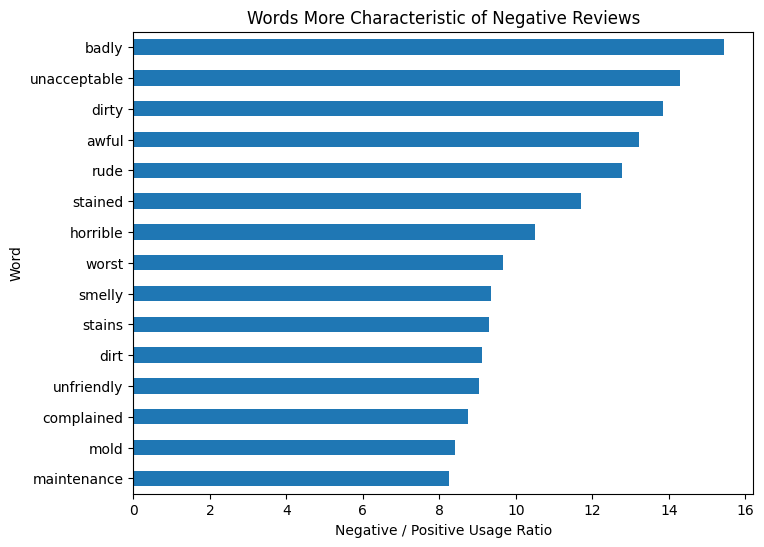

In [64]:
word_compare["negative_vs_positive_ratio"] = (
    (word_compare["negative_rate"] + 1e-6) /
    (word_compare["positive_rate"] + 1e-6)
)

distinctive_negative_words = (
    word_compare[word_compare["negative_count"] >= 20]
    .sort_values("negative_vs_positive_ratio", ascending=False)
    .head(15)
)

distinctive_negative_words.sort_values("negative_vs_positive_ratio").plot(
    x="word",
    y="negative_vs_positive_ratio",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Words More Characteristic of Negative Reviews")
plt.xlabel("Negative / Positive Usage Ratio")
plt.ylabel("Word")
plt.show()

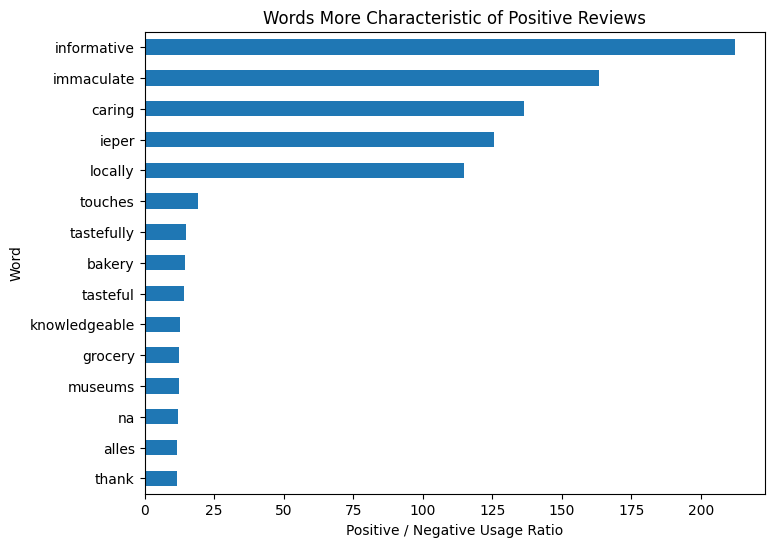

In [65]:
word_compare["positive_vs_negative_ratio"] = (
    (word_compare["positive_rate"] + 1e-6) /
    (word_compare["negative_rate"] + 1e-6)
)

distinctive_positive_words = (
    word_compare[word_compare["positive_count"] >= 20]
    .sort_values("positive_vs_negative_ratio", ascending=False)
    .head(15)
)

distinctive_positive_words.sort_values("positive_vs_negative_ratio").plot(
    x="word",
    y="positive_vs_negative_ratio",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Words More Characteristic of Positive Reviews")
plt.xlabel("Positive / Negative Usage Ratio")
plt.ylabel("Word")
plt.show()

In [66]:
df_tran.to_csv("../data/booking_reviews_with_transformers_and_no_names.csv", index=False)

In [69]:
# cretaing the topicmodeling.py with eveythingwe did:

# TF-IDF
# NMF topic modeling
# topic_id
# topic_name mapping
# topic counts
# average rating per topic
# topic by season
# topic by trip type
# topic by traveller type
# distinctive positive/negative words
# plot saving
# optional PERSON-name removal with spaCy NER
